In [1]:
!nvidia-smi

Sat Feb  7 08:02:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.52.01              Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        On  |   00000000:01:00.0  On |                  N/A |
|  0%   44C    P8             11W /  170W |    1485MiB /  12288MiB |      4%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [44]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from bs4 import BeautifulSoup
import re
import unicodedata
import itertools
from collections import Counter
import tiktoken
from sklearn.model_selection import train_test_split
import os

In [3]:
# đọc file dữ liệu lên để xử lý
path = "/data/dataset_news_summary/"
file = "Dataset_articles_NoID.csv"
df = pd.read_csv(path + file)

In [4]:
df.sample(n=5)

,URL,Title,Summary,Contents,Date,Author(s),Category,Tags
150112,https://laodong.vn/cong-doan/khanh-hoa-tang-cu...,Khánh Hòa: Tăng cường thanh tra đột xuất các đ...,"Số đơn vị, doanh nghiệp (DN) nợ bảo hiểm xã hộ...",Hơn 4.800 doanh nghiệp nợ BHXH Theo số liệu từ...,"Thứ bảy, 14/11/2020 09:09 (GMT+7)",Phương Linh,Công đoàn,"['Khánh Hòa', 'Bảo hiểm xã hội', 'Doanh nghiệp..."
181234,https://laodong.vn/the-gioi/vuong-quoc-anh-pha...,Vương quốc Anh phát hiện 6 ca đầu tiên mắc biế...,Vương quốc Anh đã phát hiện 6 ca đầu tiên mắc ...,"Reuters đưa tin, giới chức y tế Anh ngày 28.2 ...","Thứ hai, 01/03/2021 07:46 (GMT+7)",Bảo Châu,Thế giới,"['Vương quốc Anh', 'COVID-19', 'Dịch COVID-19'..."
260598,https://laodong.vn/giai-tri/ngoc-trinh-va-nhun...,"Ngọc Trinh và những mối tình gây ""ồn ào"" showb...","Chuyện tình cảm của ""Nữ hoàng nội y"" Ngọc Trin...","Mối tình với Khắc Tiệp Khắc Tiệp là ""ông bầu"" ...","Thứ năm, 07/03/2019 19:00 (GMT+7)",Linh Chi (t/h),Văn hóa - Giải trí,"['Showbiz Việt', 'Ngọc Trinh', 'Bạn trai Ngọc ..."
38999,https://laodong.vn/phap-luat/nghe-an-bat-doi-t...,"Nghệ An: Bắt đối tượng giết người, trốn truy n...",Công an Nghệ An đã phối hợp với Công an quận T...,"Ngày 25.4, theo thông tin từ Công an tỉnh Nghệ...","Thứ bảy, 25/04/2020 13:30 (GMT+7)",Tuấn Quỳnh,Pháp luật,"['Nghệ An', 'Truy nã', 'Công an Nghệ An', 'Côn..."
142458,https://laodong.vn/cong-doan/ldld-tinh-nghe-an...,LĐLĐ tỉnh Nghệ An chúc mừng các Ban xây dựng đ...,"Ngày 14.10, nhân kỷ niệm ngày truyền thống các...","Thay mặt Thường trực LĐLĐ tỉnh Nghệ An, ông Kh...","Thứ năm, 14/10/2021 17:29 (GMT+7)",Nguyễn Hương,Công đoàn,"['Chúc mừng', 'LĐLĐ tỉnh Nghệ An', 'Ban xây dự..."


In [5]:
# số dòng và số cột của bộ dữ liệu
print("Số lượng bản ghi : ", len(df))
print("số lượng cột: ", df.columns.tolist())

Số lượng bản ghi :  313320
số lượng cột:  ['URL', 'Title', 'Summary', 'Contents', 'Date', 'Author(s)', 'Category', 'Tags']


In [6]:
# kiểm tra kiểu dữ liệu, số lượng dữ liệu missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313320 entries, 0 to 313319
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   URL        313320 non-null  object
 1   Title      313320 non-null  object
 2   Summary    313140 non-null  object
 3   Contents   307763 non-null  object
 4   Date       313320 non-null  object
 5   Author(s)  312499 non-null  object
 6   Category   313320 non-null  object
 7   Tags       313320 non-null  object
dtypes: object(8)
memory usage: 19.1+ MB


In [7]:
# số lượng null ở mỗi category
print(df.isna().sum())

URL             0
Title           0
Summary       180
Contents     5557
Date            0
Author(s)     821
Category        0
Tags            0
dtype: int64


In [8]:
df_len = pd.DataFrame()

# phân tích đọ dài các trường
df_len['len_url'] = df['URL'].astype(str).apply(len)
df_len['len_title'] = df['Title'].astype(str).apply(len)
df_len['len_summary'] = df['Summary'].astype(str).apply(len)
df_len['len_contents'] = df['Contents'].astype(str).apply(len)
df_len['len_date'] = df["Date"].astype(str).apply(len)
df_len['len_authors'] = df['Author(s)'].astype(str).apply(len)
df_len['len_category'] = df['Category'].astype(str).apply(len)
df_len['len_tags'] = df['Tags'].astype(str).apply(len)

print("Mô tả thống kê về độ dài của từng category: ")
print(df_len[['len_url', "len_title", "len_summary", "len_contents",
          'len_date', 'len_authors', 'len_category', 'len_tags']].describe())

Mô tả thống kê về độ dài của từng category: 
             len_url      len_title    len_summary   len_contents  \
count  313320.000000  313320.000000  313320.000000  313320.000000   
mean      100.961231      62.492228     191.594182    2273.304076   
std        12.331939      12.409977      76.616255    1775.232845   
min        41.000000       2.000000       3.000000       3.000000   
25%        94.000000      55.000000     137.000000    1362.000000   
50%       102.000000      64.000000     177.000000    2014.000000   
75%       109.000000      70.000000     230.000000    2819.000000   
max       256.000000     222.000000    1559.000000  186322.000000   

            len_date    len_authors   len_category       len_tags  
count  313320.000000  313320.000000  313320.000000  313320.000000  
mean       32.791411       9.659648       8.753284      89.487757  
std         0.614210       5.337122       3.233486      51.405804  
min        32.000000       1.000000       4.000000       6.00

In [9]:
# Kiểm tra trùng lặp URL
duplicate_url = df['URL'].duplicated().sum()
print('Số url trùng lặp: ', duplicate_url)
# Kiểm tra trùng lặp Title
dup_title = df['Title'].duplicated().sum()
print('Số Title trùng lặp: ', dup_title)
# Kiểm tra trùng lặp Contents
dup_contents = df['Contents'].duplicated().sum()
print('Số Contents trùng lặp: ', dup_contents)
# Kiểm tra trùng lặp cả row
has_dup = df.duplicated().sum()
print('Sô dòng trùng lặp: ', has_dup)

Số url trùng lặp:  23038
Số Title trùng lặp:  24487
Số Contents trùng lặp:  28686
Sô dòng trùng lặp:  23032


In [10]:
# kiểm tra số lượng bản ghi có Title trùng Summary
same = (df['Title'] == df['Summary']).sum()
print('số lượng bản ghi có Title trùng Summary: ', same)

# in ra kiểm tra
print(df[df['Title'] == df['Summary']][['Title', 'Summary']])

số lượng bản ghi có Title trùng Summary:  5
                                                    Title  \
83059   Báo Lao Động tuyển dụng vị trí Trưởng phòng và...   
120703      Các doanh nghiệp nợ đang BHXH 3.261,5 tỉ đồng   
139126  Chính sách bảo hiểm, tiền lương có hiệu lực từ...   
139783  Agribank đồng hành cùng Báo Lao Động hỗ trợ cô...   
150154  Phát triển giai cấp Công nhân, nâng cao vai tr...   

                                                  Summary  
83059   Báo Lao Động tuyển dụng vị trí Trưởng phòng và...  
120703      Các doanh nghiệp nợ đang BHXH 3.261,5 tỉ đồng  
139126  Chính sách bảo hiểm, tiền lương có hiệu lực từ...  
139783  Agribank đồng hành cùng Báo Lao Động hỗ trợ cô...  
150154  Phát triển giai cấp Công nhân, nâng cao vai tr...  


In [36]:
# ---> cần xử lý các dữ liệu trùng lặp đã thống kê bên trên

In [37]:
# kiểm tra thống kê độ dài của các bài viết để có thể chọn mô hình phù hợp

Số bản ghi có Contents > 1200 từ: 8,241
Số bản ghi Contents < 50 từ: 7,133


Text(0, 0.5, 'Số lượng')

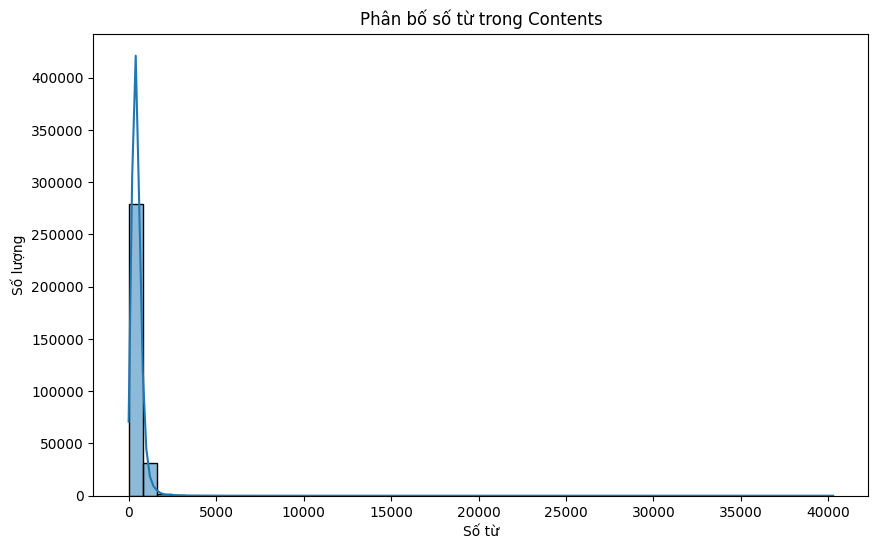

In [11]:
# số lượng bài có độ dài từ trong contents ngoài ngưỡng [50,1200] từ (ngưỡng này do tự quy định)
df['word_count'] = df['Contents'].fillna('').str.count(' ') + 1 # dếm số lượng từ trong 1 văn bản

# thống kê
under_50 = df[df['word_count'] < 50] 
over_1200 = df[df['word_count'] > 1200] 
print(f"Số bản ghi có Contents > 1200 từ: {len(over_1200):,}")
print(f"Số bản ghi Contents < 50 từ: {len(under_50):,}")

# vẽ biểu đồ biểu diễn số từ trong trường contents của data
plt.figure(figsize=(10,6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Phân bố số từ trong Contents', fontsize=12)
plt.xlabel('Số từ')
plt.ylabel('Số lượng')

# nhìn biểu đồ và thống kê có số lượng bài bái quá ngắn hoặc quá dài cũng nên xử lý

Số bản ghi có Contents > 25 từ: 429
Số bản ghi Contents < 3 từ: 42


Text(0, 0.5, 'Số lượng')

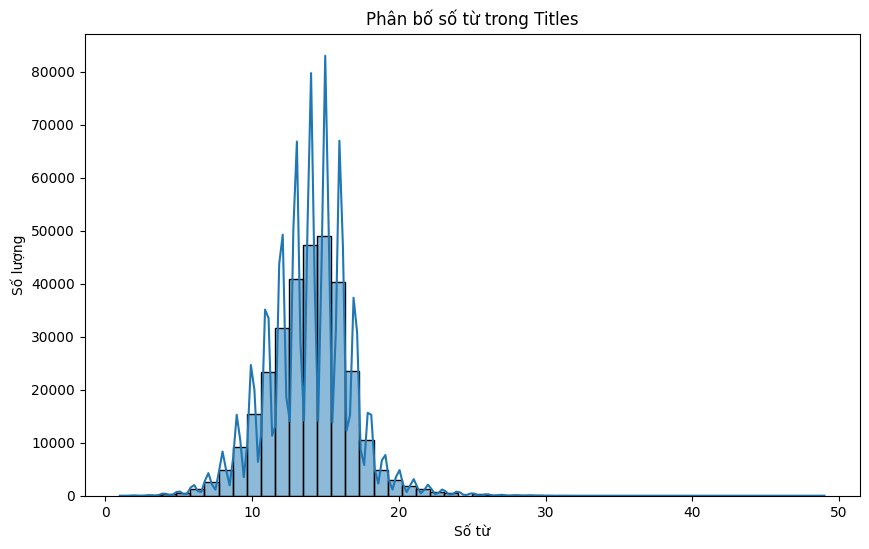

In [12]:
# tương tự với title , tiêu đề sẽ lấy ngưỡng từ [3,25]
df['word_count'] = df['Title'].fillna('').str.count(' ') + 1 # dếm số lượng từ trong 1 văn bản

# thống kê
under_3 = df[df['word_count'] < 3] 
over_25 = df[df['word_count'] > 25] 
print(f"Số bản ghi có Contents > 25 từ: {len(over_25):,}")
print(f"Số bản ghi Contents < 3 từ: {len(under_3):,}")

# vẽ biểu đồ biểu diễn số từ trong trường contents của data
plt.figure(figsize=(10,6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Phân bố số từ trong Titles', fontsize=12)
plt.xlabel('Số từ')
plt.ylabel('Số lượng')

Số bản ghi có Contents > 150 từ: 90
Số bản ghi Contents < 10 từ: 223


Text(0, 0.5, 'Số lượng')

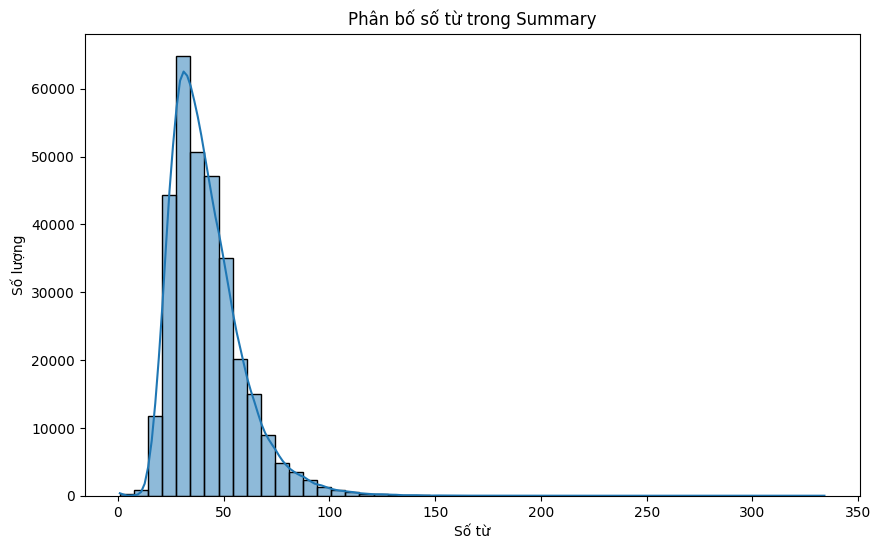

In [13]:
# tương tự với summary , tiêu đề sẽ lấy ngưỡng từ [10,150]
df['word_count'] = df['Summary'].fillna('').str.count(' ') + 1 # dếm số lượng từ trong 1 văn bản

# thống kê
under_10 = df[df['word_count'] < 10] 
over_150 = df[df['word_count'] > 150] 
print(f"Số bản ghi có Contents > 150 từ: {len(over_150):,}")
print(f"Số bản ghi Contents < 10 từ: {len(under_10):,}")

# vẽ biểu đồ biểu diễn số từ trong trường contents của data
plt.figure(figsize=(10,6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Phân bố số từ trong Summary', fontsize=12)
plt.xlabel('Số từ')
plt.ylabel('Số lượng')

ValueError: zero-size array to reduction operation fmin which has no identity

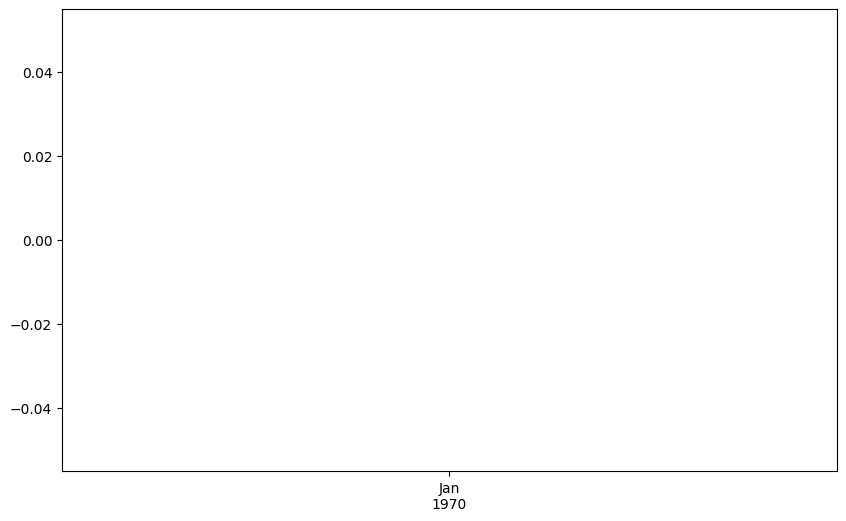

In [49]:
#  dữ liệu phân phối theo thời gian
def parse_vietnamese_date(date_str):
    try:
        # Tách phần ngày giờ (bỏ thứ và GMT)
        # VD: "Thứ năm, 18/07/2013 07:37 (GMT+7)" -> "18/07/2013 07:37"
        date_part = date_str.split(', ')[1].split(' (GMT')[0]
        return pd.to_datetime(date_part, format='%d/%m/%Y %H:%M')
    except:
        return pd.NaT

df['Date'] = df['Date'].apply(parse_vietnamese_date)

df_clean = df[df['Date'].notna()].copy()
# Tạo các cột phụ
df_clean['year'] = df_clean['Date'].dt.year
df_clean['month'] = df_clean['Date'].dt.month
df_clean['year_month'] = df_clean['Date'].dt.to_period('M')

# Biểu đồ phân phối theo tháng
plt.figure(figsize=(10, 6))
monthly_count = df_clean['year_month'].value_counts().sort_index()
monthly_count.plot(kind='line', marker='o', linewidth=2, markersize=5)
plt.xlabel('Tháng')
plt.ylabel('Số lượng bài viết')
plt.title('Phân phối số lượng bài viết theo thời gian')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()   #### ----> không chạy, đang lỗi chưa tìm được nguyên nhân, đây cũng chỉ là 
            ###     phân tích thống kê lượng bài báo theo thời gian 

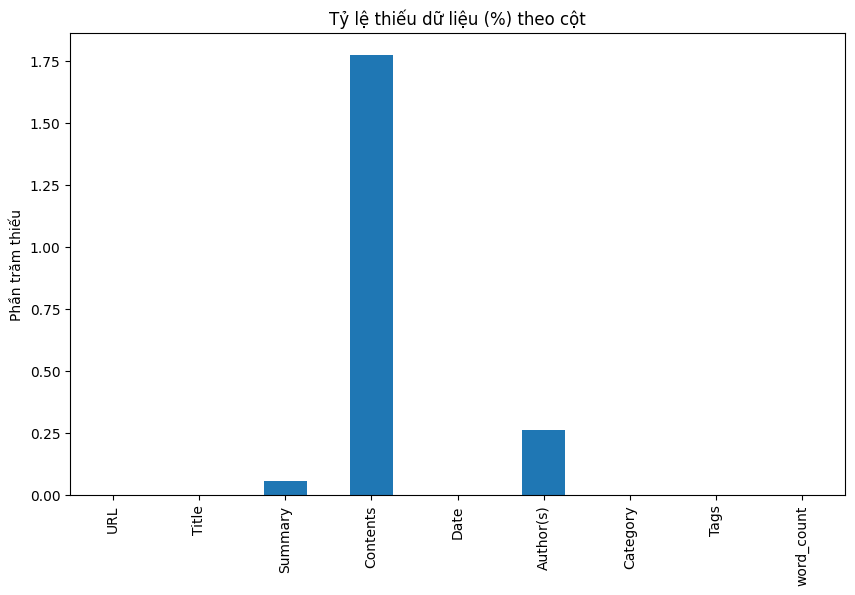

In [14]:
# tỷ lệ thiếu dữ liệu theo cột (cột bị null)

(df.isna().mean() * 100).plot(kind='bar', figsize=(10,6))
plt.title("Tỷ lệ thiếu dữ liệu (%) theo cột")
plt.ylabel("Phần trăm thiếu")
plt.show()

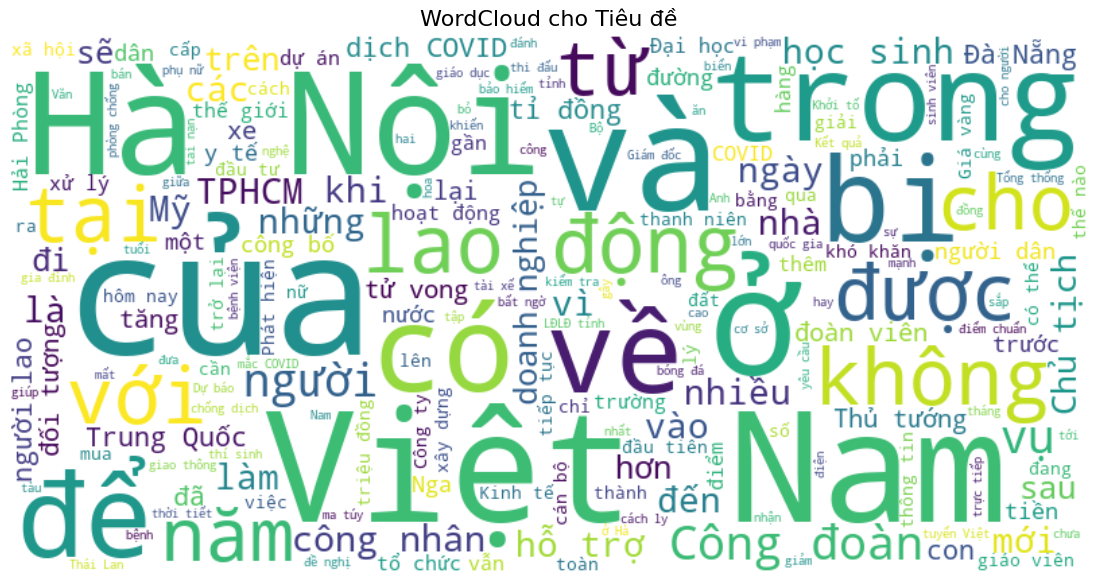

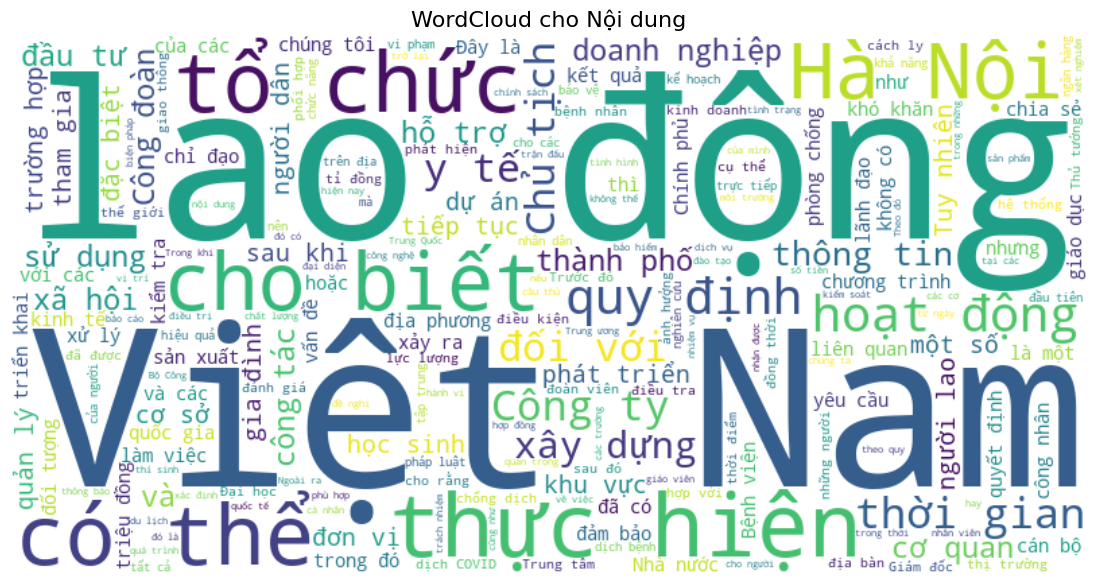

In [15]:
# tạo WordCloud (ảnh về tần xuất xuất của các từ, trực quan dễ thấy từ nào hay xuất hiện)
sample_size = min(10000, len(df))  # Chỉ lấy tối đa 10000 dòng
df_sample = df.sample(n=sample_size, random_state=42)

text_titles = " ".join(df_sample["Title"].dropna().astype(str).tolist())
text_contents = " ".join(df_sample["Contents"].dropna().astype(str).tolist())

plt.figure(figsize=(14,7))
wc_title = WordCloud(width=800, height=400, background_color="white").generate(text_titles)
plt.imshow(wc_title, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud cho Tiêu đề", fontsize=16)
plt.show()

plt.figure(figsize=(14,7))
wc_content = WordCloud(width=800, height=400, background_color="white").generate(text_contents)
plt.imshow(wc_content, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud cho Nội dung", fontsize=16)
plt.show()

In [68]:
# sau khi phân tích và thống kê bên trên, sẽ tiến hành processing dữ liệu

In [16]:
# loaị bỏ thẻ HTML, ký tự đặc biệt và hiệu chỉnh chuẩn hóa chính tả
def clean_html(text):
  if pd.isna(text): return ''

  text = BeautifulSoup(text, 'html.parser').get_text(separator=' ') # loại bỏ thẻ html
  text = re.sub(r'https?://\S+', ' ', text) # loại bỏ link
  text = re.sub(r'\s+', ' ', text).strip() # bỏ white_space
  return text


def normalize_unicode(text):
    return unicodedata.normalize('NFC', text) 


VIETNAMESE_ABBR = {
    r'\bTp[\. ]? ?HCM\b': 'TP.HCM',
    r'\bTP[\. ]? ?HCM\b': 'TP.HCM',
    r'\bHà ?nội\b': 'Hà Nội',
    r'\bViệt ?nam\b': 'Việt Nam',
    r'\bVN\b': 'Việt Nam',
    r'\bvnđ\b': 'đồng',
    r'\bTp[\.]?\b': 'TP.',
}

def normalize_common_phrases(text):
    '''
    chuẩn hóa chính tả
    '''
    for pattern, repl in VIETNAMESE_ABBR.items():
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    return text

def normalize_special_tokens(text):
    text = re.sub(r'@\w+', '<USER>', text) # re thay thế mention 
    text = re.sub(r'#\w+', '<HASHTAG>', text) # re thay thế tags
    text = re.sub(r'https?://\S+', '<URL>', text)
    return text

def normalize_vietnamese_text(text):
    text = clean_html(text)
    text = normalize_unicode(text)
    text = normalize_common_phrases(text)
    text = normalize_special_tokens(text)
    return text.strip()

for col in ['Title', 'Summary', 'Contents']:
    df[col] = df[col].astype(str).apply(normalize_vietnamese_text)

In [ ]:
# đếm số lượng các từ trong contents
# sau khi counter giống như bag of words --> không chạy lệnh này vì rất lâu
words = list(itertools.chain.from_iterable(df["Contents"].str.split()))
Counter(words).most_common(20)

In [17]:
print(df[['Contents']].describe()) # thống kê contents sau khi xử lý 

       Contents
count    313320
unique   284609
top         nan
freq       5557


In [20]:
# loại bỏ các record bị duplicate

In [18]:
# loai bỏ các bản ghi trùng nhau hoàn toàn (tất cả các category giống nhau)
print("Trước khi loại duplicate:", len(df))
df = df.drop_duplicates(keep = 'first')
df = df.drop_duplicates(subset=['Contents'], keep='first') # 2 bản ghi có conten giống nhau cũng coi là trùng
df = df.reset_index(drop=True)

print("Sau khi loại bỏ duplicate, và duplicate contens: ", len(df))

Trước khi loại duplicate: 313320
Sau khi loại bỏ duplicate, và duplicate contens:  284609


In [19]:
# loại bỏ những những bài báo có title == summary
before = len(df)
df = df[df['Title'] != df['Summary']].reset_index(drop=True)
print(f"Đã xóa {before - len(df):,} → Còn {len(df):,} dòng")

Đã xóa 5 → Còn 284,604 dòng


In [20]:
# kiểm tra lại
same = (df['Title'] == df['Summary']).sum()
print('Số dòng có title trùng summary: ', same)

Số dòng có title trùng summary:  0


In [21]:
# loại bỏ bản ghi có content hoặc summary bị null
before = len(df)
df = df.dropna(subset=['Contents']) # xóa bản ghi bị NaN
df = df[df['Contents'].str.strip() != ''] # Xóa bản ghi ''
df = df.reset_index(drop=True)
print(f'Số bản ghi đã xóa {before - len(df)}' )

Số bản ghi đã xóa 0


In [22]:
before = len(df)
df = df.dropna(subset=['Summary']) # xóa bản ghi bị NaN
df = df[df['Summary'].str.strip() != ''] # Xóa bản ghi ''
df = df.reset_index(drop=True)
print(f'Số bản ghi đã xóa {before - len(df)}' )

Số bản ghi đã xóa 0


In [23]:
# Kiểm tra lại cột null
print(df.isna().sum())

URL             0
Title           0
Summary         0
Contents        0
Date            0
Author(s)     635
Category        0
Tags            0
word_count      0
dtype: int64


In [32]:
# loại bỏ các bản ghi có content, summary, tiltle vượt ngưỡng

In [24]:
# Content
word_counts = df['Contents'].fillna('').str.count(' ')
# lọc ngưỡng [50,1200]
df = df[(word_counts >= 49 ) & (word_counts <= 1199)].reset_index(drop=True)
print(f"Sau khi lọc: {len(df):,} dòng")
print(f"Đã xóa các bài < 50 từ và > 1200 từ")

Sau khi lọc: 276,178 dòng
Đã xóa các bài < 50 từ và > 1200 từ


In [25]:
# Title
word_counts = df['Title'].fillna('').str.count(' ')
# lọc ngưỡng [3,25]
df = df[(word_counts >= 2 ) & (word_counts <= 24)].reset_index(drop=True)
print(f"Sau khi lọc: {len(df):,} dòng")
print(f"Đã xóa các bài < 3 từ và > 25 từ")

Sau khi lọc: 275,856 dòng
Đã xóa các bài < 3 từ và > 25 từ


In [26]:
# Summary
word_counts = df['Summary'].fillna('').str.count(' ')
# lọc ngưỡng [10,150]
df = df[(word_counts >= 9 ) & (word_counts <= 149)].reset_index(drop=True)
print(f"Sau khi lọc: {len(df):,} dòng")
print(f"Đã xóa các bài < 10 từ và > 150 từ")

Sau khi lọc: 275,650 dòng
Đã xóa các bài < 10 từ và > 150 từ


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275650 entries, 0 to 275649
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   URL         275650 non-null  object
 1   Title       275650 non-null  object
 2   Summary     275650 non-null  object
 3   Contents    275650 non-null  object
 4   Date        275650 non-null  object
 5   Author(s)   275290 non-null  object
 6   Category    275650 non-null  object
 7   Tags        275650 non-null  object
 8   word_count  275650 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 18.9+ MB


In [28]:
# xóa cột không cần thiết dữ lại title, content, summary
df = df[['Title', 'Contents', 'Summary', 'Category']]

In [29]:
df.sample(n=1)

,Title,Contents,Summary,Category
119155,Trao hàng nghìn suất quà cho công nhân lao độn...,"Ngày 7.1, Công đoàn Khu kinh tế Nghi Sơn và cá...","Thanh Hóa - Trong năm 2021, Công đoàn Khu kinh...",Công đoàn


In [30]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Contents'].fillna('').str.count(' ') + 1

under_50 = (df['word_count'] < 50).sum()
over_1200 = (df['word_count'] > 1200).sum()

print(f"< 50 từ: {under_50:,} ({under_50/len(df)*100:.2f}%)")
print(f"> 1200 từ: {over_1200:,} ({over_1200/len(df)*100:.2f}%)")
print(f"Trung bình: {df['word_count'].mean():.1f} từ")

< 50 từ: 0 (0.00%)
> 1200 từ: 0 (0.00%)
Trung bình: 468.3 từ


In [31]:
# kiểm tra duplicate các bản ghi
has_dup = df.duplicated().sum()
print(f'số dòng bị dup {has_dup}')

số dòng bị dup 0


In [32]:
print(df.isna().sum()) # xem có cột nào có bản ghi NaN không

Title         0
Contents      0
Summary       0
Category      0
word_count    0
dtype: int64


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275650 entries, 0 to 275649
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Title       275650 non-null  object
 1   Contents    275650 non-null  object
 2   Summary     275650 non-null  object
 3   Category    275650 non-null  object
 4   word_count  275650 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 10.5+ MB


In [34]:
# kiểm tra lại có còn bản ghi nào mà title trùng summary không
same_count = (df['Title'] == df['Summary']).sum()
print(f"Số dòng có Title giống Summary: {same_count}")

# Nếu còn thì xem các dòng giống nhau
if same_count > 0:
    same_rows = df[df['Title'] == df['Summary']]
    print(f"\nVí dụ {min(3, len(same_rows))} dòng giống nhau:")
    for idx, row in same_rows.head(3).iterrows():
        print(f"\n  Index {idx}:")
        print(f"  Title: {row['Title']}")
        print(f"  Summary: {row['Summary']}")

Số dòng có Title giống Summary: 0


In [35]:
# kiểm tra lại số lượng bài ngoài ngưỡng
df['word_count'] = df['Summary'].fillna('').str.count(' ') + 1

# Thống kê
under_10 = df[df['word_count'] < 10]
print(f"Số dòng có Summary < 10 từ: {len(under_10):,}")

over_150 = df[df['word_count'] > 150]
print(f"Số dòng có Summary > 150 từ: {len(over_150):,}")

Số dòng có Summary < 10 từ: 0
Số dòng có Summary > 150 từ: 0


In [36]:
# kiểm tra lại số lượng bài ngoài ngưỡng
df['word_count'] = df['Title'].fillna('').str.count(' ') + 1

# Thống kê
under_10 = df[df['word_count'] < 3]
print(f"Số dòng có Summary < 3 từ: {len(under_10):,}")

over_150 = df[df['word_count'] > 25]
print(f"Số dòng có Summary > 25 từ: {len(over_150):,}")

Số dòng có Summary < 3 từ: 0
Số dòng có Summary > 25 từ: 0


In [37]:
# kiểm tra lại số lượng bài ngoài ngưỡng
df['word_count'] = df['Contents'].fillna('').str.count(' ') + 1

# Thống kê
under_10 = df[df['word_count'] < 50]
print(f"Số dòng có Summary < 50 từ: {len(under_10):,}")

over_150 = df[df['word_count'] > 1200]
print(f"Số dòng có Summary > 1200 từ: {len(over_150):,}")

Số dòng có Summary < 50 từ: 0
Số dòng có Summary > 1200 từ: 0


In [38]:
# khởi tạo và kiểm tra số lượng sử dụng của bộ dataset
# không phải để ý đến hàm này, hàm này chỉ kiểm tra số lượng token 
tqdm.pandas()
encoding = tiktoken.get_encoding('cl100k_base')
def count_tokens_batch(texts):
    '''
    Đếm tokens cho nhiều văn bản
    '''
    tokens_list = []
    for text in tqdm(texts, desc="Counting tokens"):
        if pd.isna(text) or text == '':
            tokens_list.append(0)
        else:
            tokens_list.append(len(encoding.encode(str(text))))
    return np.array(tokens_list)

# Đếm tokens
print("Đang đếm tokens cho Title...")
title_tokens = count_tokens_batch(df['Title'].values)

print("Đang đếm tokens cho Contents...")
contents_tokens = count_tokens_batch(df['Contents'].values)

# Lưu vào DataFrame
df['title_tokens'] = title_tokens
df['contents_tokens'] = contents_tokens
df['total_tokens'] = title_tokens + contents_tokens

# Thống kê
print("\n" + "=" * 60)
print("📊 KẾT QUẢ:")
print("=" * 60)
print(f"Tổng tokens toàn dataset: {df['total_tokens'].sum():,}")
print(f"Trung bình tokens/bài: {df['total_tokens'].mean():.1f}")

Đang đếm tokens cho Title...


Counting tokens: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 275650/275650 [00:01<00:00, 138140.75it/s]


Đang đếm tokens cho Contents...


Counting tokens: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 275650/275650 [00:48<00:00, 5650.35it/s]


📊 KẾT QUẢ:
Tổng tokens toàn dataset: 298,402,804
Trung bình tokens/bài: 1082.5


In [39]:
# số lượng bài báo theo mỗi chủ đề
category_counts = df['Category'].value_counts()
print(category_counts)

Category
Xã hội                        53264
Thể thao                      30219
Pháp luật                     27844
Thế giới                      27741
Kinh doanh                    26042
Công đoàn                     22233
Văn hóa - Giải trí            18092
Thời sự                       14590
Giáo dục                      11271
Sức khỏe                      10857
Bạn đọc                        7961
Media                          7194
Bất động sản                   5634
Gia đình - Hôn nhân            4207
Xe +                           3671
Tấm Lòng Vàng                  1832
Công nghệ                      1323
Lưu trữ                         401
Diễn đàn                        277
Tin tức việc làm                269
Tin hoạt động                   220
Lao Động & Đời sống             163
Lao Động cuối tuần              156
Sự kiện Bình luận                57
Tin địa phương                   32
Quỹ TLV                          27
Thông tin doanh nghiệp           13
Tin bài xem thêm   

In [40]:
MIN_SAMPLES = 100

category_counts = df['Category'].value_counts()
rare_categories = category_counts[category_counts < MIN_SAMPLES].index

df['Category'] = df['Category'].replace(rare_categories, 'Other')

In [41]:
category_counts = df['Category'].value_counts()
print(category_counts)

Category
Xã hội                 53264
Thể thao               30219
Pháp luật              27844
Thế giới               27741
Kinh doanh             26042
Công đoàn              22233
Văn hóa - Giải trí     18092
Thời sự                14590
Giáo dục               11271
Sức khỏe               10857
Bạn đọc                 7961
Media                   7194
Bất động sản            5634
Gia đình - Hôn nhân     4207
Xe +                    3671
Tấm Lòng Vàng           1832
Công nghệ               1323
Lưu trữ                  401
Diễn đàn                 277
Tin tức việc làm         269
Tin hoạt động            220
Other                    189
Lao Động & Đời sống      163
Lao Động cuối tuần       156
Name: count, dtype: int64


In [42]:
# chia dataset 
df = df[['Title', 'Summary', 'Contents', 'Category']].dropna().reset_index(drop=True)

train_val_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['Category']
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=1/9,
    random_state=42,
    stratify=train_val_df['Category']
)

In [45]:
# lưu về dạng csv
os.makedirs("/data/dataset_news_summary/text_rank_summary/csv", exist_ok=True)  

# Kaggle
train_df.to_csv("/data/dataset_news_summary/text_rank_summary/csv/dataset_train.csv", index=False)
val_df.to_csv("/data/dataset_news_summary/text_rank_summary/csv/dataset_val.csv", index=False)
test_df.to_csv("/data/dataset_news_summary/text_rank_summary/csv/dataset_test.csv", index=False)

print("Đã lưu thành công 3 file:")

Đã lưu thành công 3 file:


In [48]:
# lưu về dạng json
os.makedirs("/data/dataset_news_summary/text_rank_summary/json", exist_ok=True)  

# Kaggle
train_df.to_json("/data/dataset_news_summary/text_rank_summary/json/dataset_train.json",
                 orient="records", force_ascii=False,indent=2)
val_df.to_json("/data/dataset_news_summary/text_rank_summary/json/dataset_val.json",
              orient="records", force_ascii=False,indent=2)
test_df.to_json("/data/dataset_news_summary/text_rank_summary/json/dataset_test.json",
               orient="records", force_ascii=False,indent=2)

print("Đã lưu thành công 3 file:")

Đã lưu thành công 3 file:
